# Customer Spending Behavior Estimation — BFSI Risk Analytics

## Problem Context

A digital banking platform processes a massive volume of customer transactions every day while
maintaining detailed records of user behavior, including spending habits, credit utilization,
account activity, and transaction frequency. Customer financial activity varies widely based on
demographic factors, credit limits, and historical usage patterns.

**Objective:** Estimate and understand customer spending behavior to support financial planning,
revenue forecasting, and better credit decision strategies.

**Challenges:**
- High behavioral diversity across customers
- Nonlinear relationships between credit usage and spending
- Outliers from extreme transaction behavior or irregular financial activity

**Approach:** This is framed as a regression problem — predict `monthly_spend` per customer from
demographic, credit, and behavioral features — using a pipeline that explicitly addresses the three
challenges above (diversity → rich segment/region features, nonlinearity → tree-based ensembles,
outliers → IQR detection + winsorization).

## Notebook Roadmap

1. **Data** — load/generate customer-level data
2. **Exploratory Data Analysis** — distributions, correlations, nonlinearity checks
3. **Outlier Treatment** — IQR detection + winsorization
4. **Feature Engineering** — encoding, log/polynomial terms
5. **Train/Test Split**
6. **Modeling** — Linear Regression baseline vs. Random Forest / Gradient Boosting
7. **Evaluation** — RMSE / MAE / R² / MAPE, cross-validation, residual diagnostics
8. **Business Application** — segment & credit-band spend estimates, risk flagging
9. **Conclusion & Next Steps**

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data

No transaction-level extract was provided alongside this brief, so the cell below **generates a
synthetic customer dataset** that mimics the patterns described in the problem statement: income-
and tenure-linked credit limits, skewed utilization, a nonlinear utilization → spend relationship,
and a small share of injected outliers (extreme splurges + dormant accounts).

> **To use real data:** replace the `generate_customer_dataset(...)` call with
> `df = pd.read_csv("your_transactions.csv")`, keeping (or remapping) the column names used below:
> `age, segment, region, tenure_months, monthly_income, credit_limit, credit_utilization,
> transaction_frequency, prior_3m_avg_spend, monthly_spend`.

In [2]:
def generate_customer_dataset(n_customers=8000, seed=42):
    rng = np.random.default_rng(seed)

    segments = np.array(["Salaried", "Self-Employed", "Retired", "Student"])
    segment_probs = [0.55, 0.25, 0.10, 0.10]
    segment_income_mult = {"Salaried": 1.0, "Self-Employed": 1.15, "Retired": 0.70, "Student": 0.35}
    segment_spend_mult = {"Salaried": 1.0, "Self-Employed": 1.10, "Retired": 0.70, "Student": 0.60}

    regions = np.array(["North", "South", "East", "West"])
    region_probs = [0.30, 0.30, 0.20, 0.20]

    segment_arr = rng.choice(segments, size=n_customers, p=segment_probs)
    region_arr = rng.choice(regions, size=n_customers, p=region_probs)

    age = rng.integers(21, 66, size=n_customers)
    tenure_months = rng.integers(1, 181, size=n_customers)

    base_income = rng.lognormal(mean=10.8, sigma=0.45, size=n_customers)
    income_mult = np.array([segment_income_mult[s] for s in segment_arr])
    monthly_income = np.clip(base_income * income_mult, 12000, 400000)

    credit_limit = monthly_income * rng.uniform(1.5, 4.0, size=n_customers) * (1 + 0.0015 * tenure_months)
    credit_limit = np.clip(credit_limit, 20000, 1500000)

    credit_utilization = np.clip(rng.beta(2.0, 3.0, size=n_customers), 0.01, 0.98)

    transaction_frequency = np.clip(
        rng.poisson(lam=8 + monthly_income / 20000, size=n_customers), 1, 80
    )

    spend_mult = np.array([segment_spend_mult[s] for s in segment_arr])
    # Nonlinear driver #1: spend ramps up faster than linearly as utilization climbs
    utilization_effect = credit_limit * (credit_utilization ** 1.6)
    frequency_effect = transaction_frequency * 350
    # Nonlinear driver #2: a regime shift past ~70% utilization ("near-limit" behavior) —
    # a kink that plain polynomial/interaction terms don't fully linearize, but tree splits do
    high_utilization_regime = np.where(credit_utilization > 0.70, credit_limit * 0.35, 0.0)

    spend_mean = (
        0.12 * monthly_income + 0.55 * utilization_effect + frequency_effect + high_utilization_regime
    ) * spend_mult

    prior_3m_avg_spend = np.clip(
        spend_mean * rng.uniform(0.8, 1.2, size=n_customers) + rng.normal(0, spend_mean * 0.10), 0, None
    )

    # Heteroscedastic noise: higher spenders show higher variance
    noise = rng.normal(0, spend_mean * 0.18, size=n_customers)
    monthly_spend = spend_mean + noise

    # Inject realistic outliers: extreme splurges and dormant low-spend accounts
    outlier_idx = rng.choice(n_customers, size=int(0.02 * n_customers), replace=False)
    monthly_spend[outlier_idx] *= rng.uniform(3.0, 6.0, size=len(outlier_idx))

    dormant_idx = rng.choice(n_customers, size=int(0.01 * n_customers), replace=False)
    monthly_spend[dormant_idx] = rng.uniform(0, 500, size=len(dormant_idx))

    monthly_spend = np.clip(monthly_spend, 0, None)

    df = pd.DataFrame({
        "customer_id": [f"CUST{100000+i}" for i in range(n_customers)],
        "age": age,
        "segment": segment_arr,
        "region": region_arr,
        "tenure_months": tenure_months,
        "monthly_income": monthly_income.round(2),
        "credit_limit": credit_limit.round(2),
        "credit_utilization": credit_utilization.round(3),
        "transaction_frequency": transaction_frequency,
        "prior_3m_avg_spend": prior_3m_avg_spend.round(2),
        "monthly_spend": monthly_spend.round(2),
    })
    return df


df = generate_customer_dataset(n_customers=8000, seed=RANDOM_STATE)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8000, 11)


,customer_id,age,segment,region,tenure_months,monthly_income,credit_limit,credit_utilization,transaction_frequency,prior_3m_avg_spend,monthly_spend
0,CUST100000,52,Self-Employed,South,163,"51,444.46","189,137.58",0.20,8,"26,474.08","19,772.68"
1,CUST100001,50,Salaried,West,134,"53,731.58","217,832.86",0.52,9,"44,199.26","34,493.18"
2,CUST100002,62,Retired,North,38,"24,758.82","56,503.95",0.22,11,"7,891.68","5,107.75"
3,CUST100003,37,Self-Employed,North,180,"67,492.04","311,748.04",0.50,13,"74,454.08","74,398.11"
4,CUST100004,54,Salaried,East,179,"64,662.89","177,628.23",0.75,13,"156,137.29","123,125.56"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            8000 non-null   str    
 1   age                    8000 non-null   int64  
 2   segment                8000 non-null   str    
 3   region                 8000 non-null   str    
 4   tenure_months          8000 non-null   int64  
 5   monthly_income         8000 non-null   float64
 6   credit_limit           8000 non-null   float64
 7   credit_utilization     8000 non-null   float64
 8   transaction_frequency  8000 non-null   int64  
 9   prior_3m_avg_spend     8000 non-null   float64
 10  monthly_spend          8000 non-null   float64
dtypes: float64(5), int64(3), str(3)
memory usage: 687.6 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"8,000.00",42.99,13.08,21.00,32.00,43.00,54.00,65.00
tenure_months,"8,000.00",90.92,52.06,1.00,46.00,91.00,136.00,180.00
monthly_income,"8,000.00","51,761.67","28,331.67","12,000.00","31,758.46","46,645.30","65,012.39","295,638.06"
credit_limit,"8,000.00","162,195.87","102,748.50","20,000.00","89,962.17","137,624.71","207,625.44","1,343,526.88"
credit_utilization,"8,000.00",0.40,0.20,0.01,0.24,0.38,0.54,0.98
transaction_frequency,"8,000.00",10.57,3.53,1.00,8.00,10.00,13.00,26.00
prior_3m_avg_spend,"8,000.00","36,079.82","40,736.96","1,292.49","13,642.50","24,025.33","42,820.22","610,611.58"
monthly_spend,"8,000.00","38,048.47","47,127.99",0.54,"13,225.33","24,180.50","44,274.51","706,037.02"


## 2. Exploratory Data Analysis

In [5]:
print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

customer_id              0
age                      0
segment                  0
region                   0
tenure_months            0
monthly_income           0
credit_limit             0
credit_utilization       0
transaction_frequency    0
prior_3m_avg_spend       0
monthly_spend            0
dtype: int64


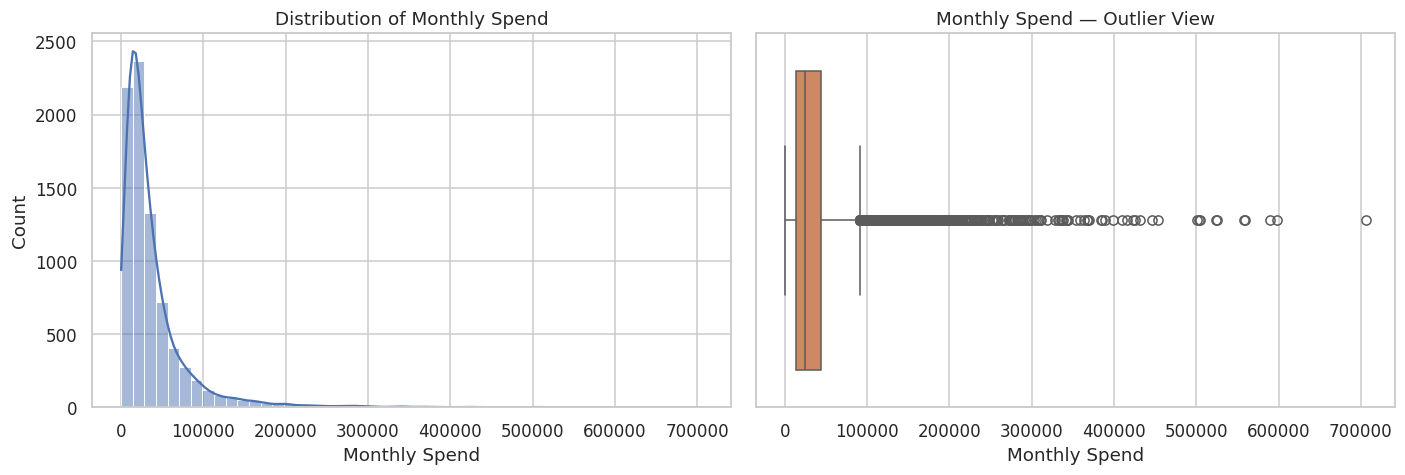

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["monthly_spend"], bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Monthly Spend")
axes[0].set_xlabel("Monthly Spend")

sns.boxplot(x=df["monthly_spend"], ax=axes[1], color="#DD8452")
axes[1].set_title("Monthly Spend — Outlier View")
axes[1].set_xlabel("Monthly Spend")

plt.tight_layout()
plt.show()

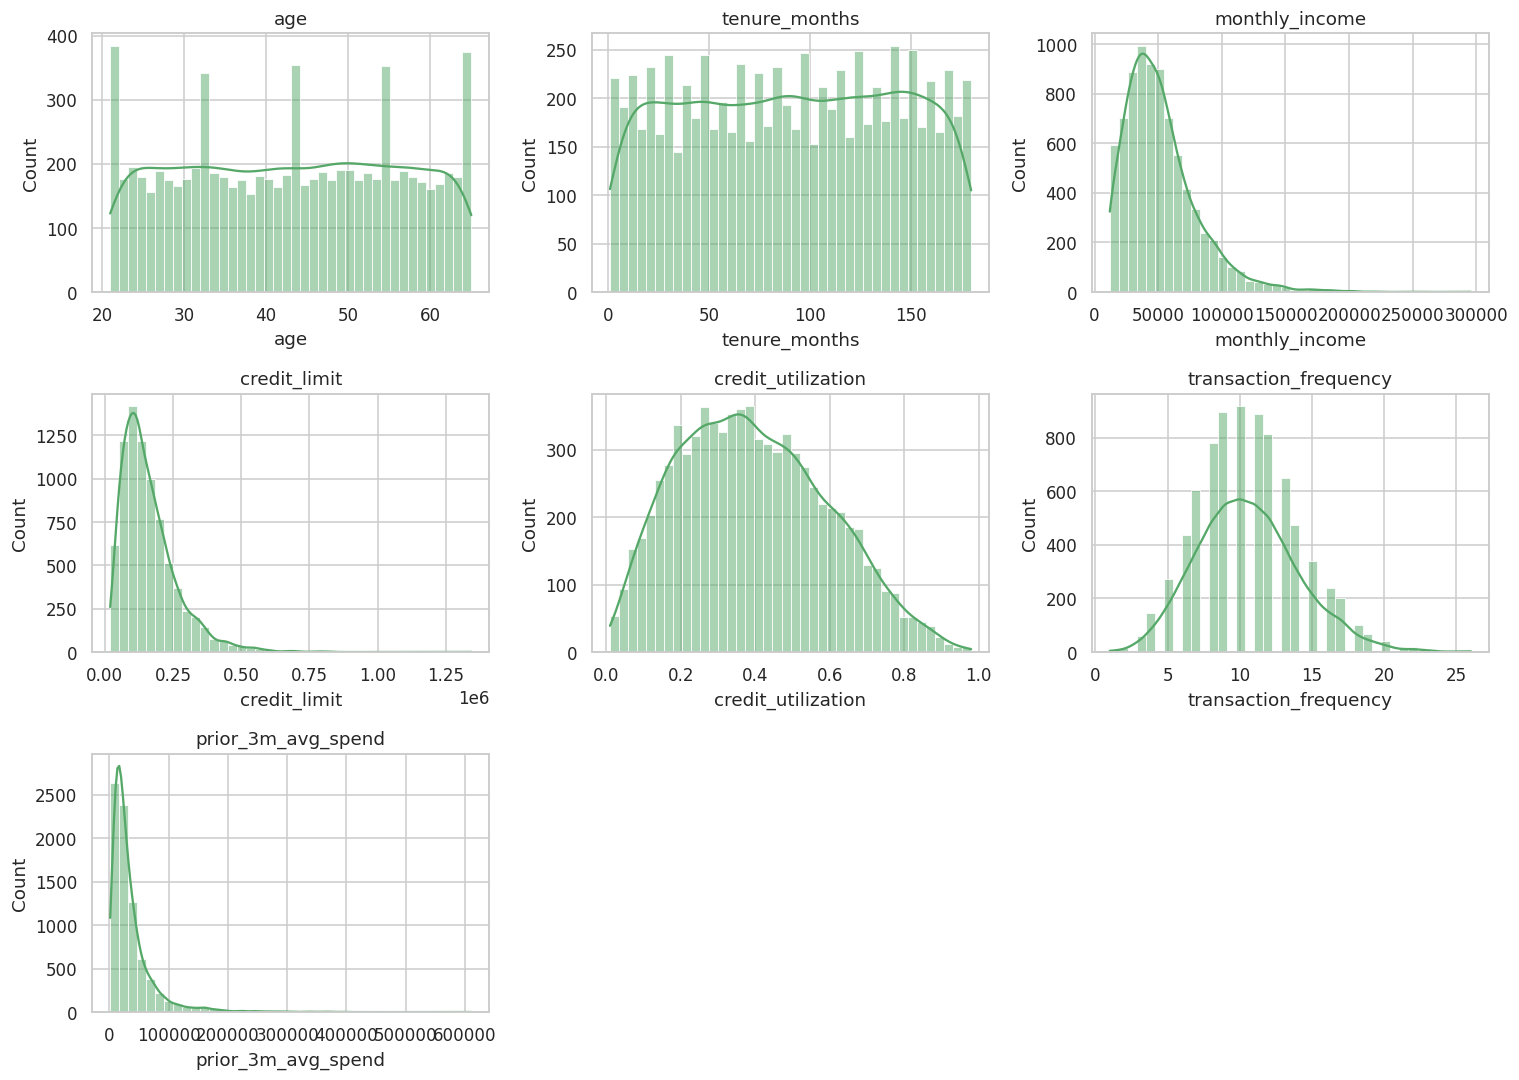

In [7]:
numeric_cols = ["age", "tenure_months", "monthly_income", "credit_limit",
                "credit_utilization", "transaction_frequency", "prior_3m_avg_spend"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color="#55A868")
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

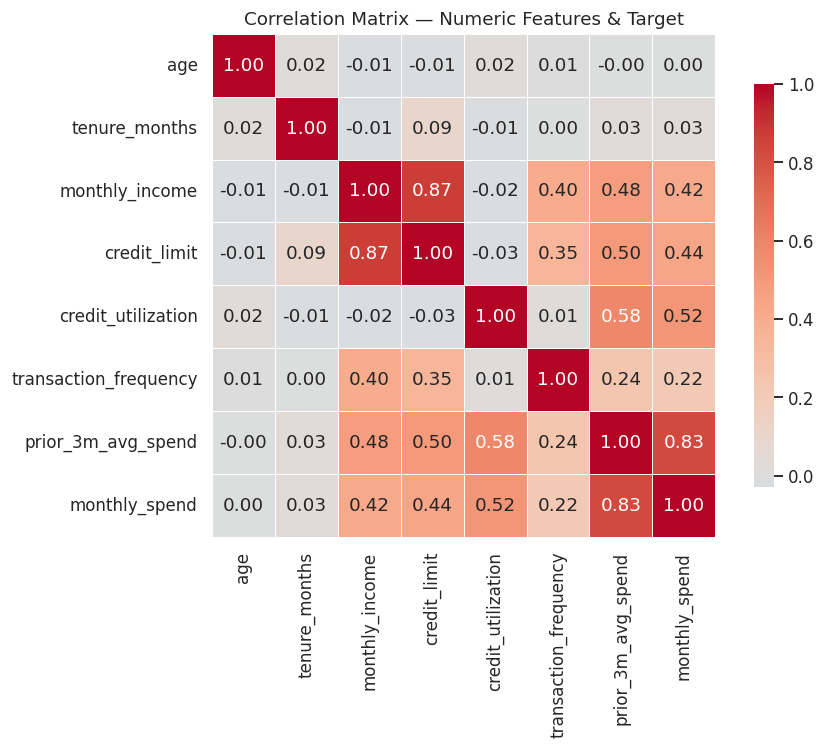

In [8]:
corr_cols = numeric_cols + ["monthly_spend"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Numeric Features & Target")
plt.tight_layout()
plt.show()

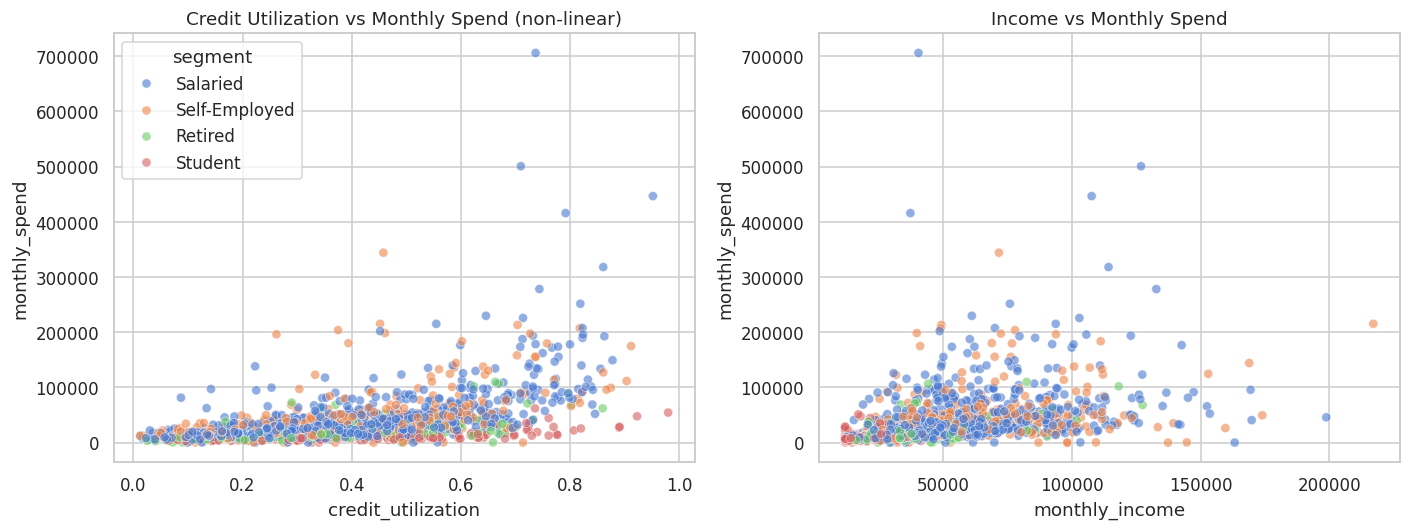

In [9]:
sample = df.sample(1500, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=sample, x="credit_utilization", y="monthly_spend",
                hue="segment", alpha=0.6, ax=axes[0])
axes[0].set_title("Credit Utilization vs Monthly Spend (non-linear)")

sns.scatterplot(data=sample, x="monthly_income", y="monthly_spend",
                hue="segment", alpha=0.6, ax=axes[1], legend=False)
axes[1].set_title("Income vs Monthly Spend")

plt.tight_layout()
plt.show()

**Reading the EDA:** spend is right-skewed with a heavy tail (the injected high-spend outliers),
and the utilization–spend relationship visibly curves upward rather than following a straight
line — exactly the two challenges called out in the problem statement. This motivates outlier
treatment before modeling, and a nonlinear model family in addition to a linear baseline.

## 3. Outlier Treatment

Outliers are detected with the IQR rule and then **winsorized** (capped at the 1st/99th
percentile) rather than dropped — this preserves sample size while preventing a handful of
extreme transactors from dominating the loss function during training.

In [10]:
def iqr_outlier_report(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    pct_outliers = ((series < lower) | (series > upper)).mean() * 100
    return lower, upper, pct_outliers

for col in ["monthly_spend", "credit_utilization", "transaction_frequency"]:
    lower, upper, pct = iqr_outlier_report(df[col])
    print(f"{col:25s} | bounds=({lower:,.2f}, {upper:,.2f}) | outliers={pct:.2f}%")

monthly_spend             | bounds=(-33,348.43, 90,848.27) | outliers=7.75%
credit_utilization        | bounds=(-0.20, 0.98) | outliers=0.03%
transaction_frequency     | bounds=(0.50, 20.50) | outliers=0.69%


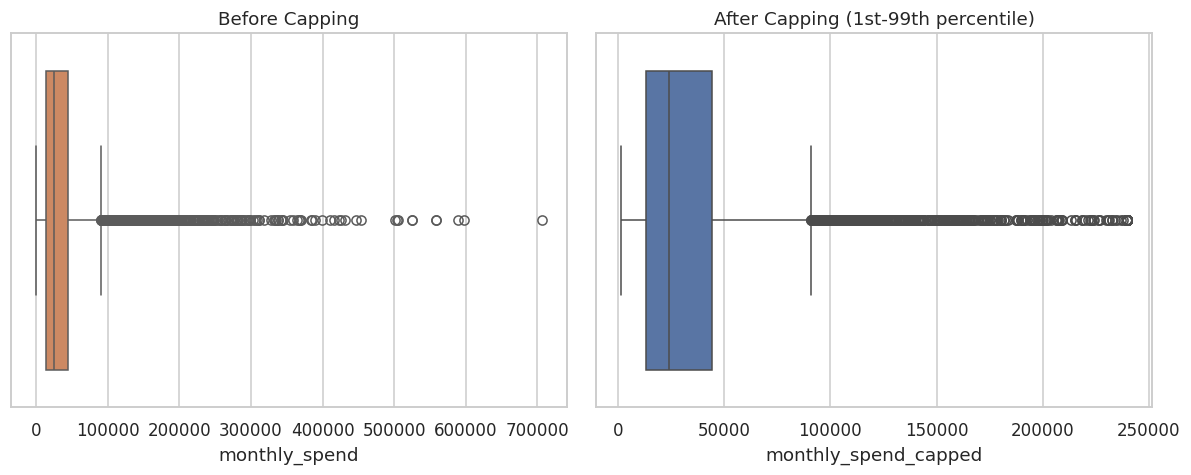

In [11]:
def winsorize(series, lower_pct=0.01, upper_pct=0.99):
    lower, upper = series.quantile([lower_pct, upper_pct])
    return series.clip(lower, upper)

df["monthly_spend_capped"] = winsorize(df["monthly_spend"])
df["prior_3m_avg_spend_capped"] = winsorize(df["prior_3m_avg_spend"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(x=df["monthly_spend"], ax=axes[0], color="#DD8452")
axes[0].set_title("Before Capping")
sns.boxplot(x=df["monthly_spend_capped"], ax=axes[1], color="#4C72B0")
axes[1].set_title("After Capping (1st-99th percentile)")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

- One-hot encode `segment` and `region` to capture behavioral diversity across customer groups
- Add log transforms for skewed monetary fields and explicit nonlinear/interaction terms so that
  even the linear baseline gets a fair chance at the curved utilization → spend relationship

In [12]:
model_df = df.copy()

model_df["log_income"] = np.log1p(model_df["monthly_income"])
model_df["log_credit_limit"] = np.log1p(model_df["credit_limit"])
model_df["utilization_sq"] = model_df["credit_utilization"] ** 2
model_df["limit_utilization_interaction"] = model_df["credit_limit"] * model_df["credit_utilization"]

model_df = pd.get_dummies(model_df, columns=["segment", "region"], drop_first=True)

exclude_cols = ["customer_id", "monthly_spend", "monthly_spend_capped", "prior_3m_avg_spend"]
feature_cols = [c for c in model_df.columns if c not in exclude_cols]

print(f"Total engineered features: {len(feature_cols)}")
model_df[feature_cols].head()

Total engineered features: 17


,age,tenure_months,monthly_income,credit_limit,credit_utilization,transaction_frequency,prior_3m_avg_spend_capped,log_income,log_credit_limit,utilization_sq,limit_utilization_interaction,segment_Salaried,segment_Self-Employed,segment_Student,region_North,region_South,region_West
0,52,163,"51,444.46","189,137.58",0.20,8,"26,474.08",10.85,12.15,0.04,"38,394.93",False,True,False,False,True,False
1,50,134,"53,731.58","217,832.86",0.52,9,"44,199.26",10.89,12.29,0.27,"112,401.76",True,False,False,False,False,True
2,62,38,"24,758.82","56,503.95",0.22,11,"7,891.68",10.12,10.94,0.05,"12,261.36",False,False,False,True,False,False
3,37,180,"67,492.04","311,748.04",0.50,13,"74,454.08",11.12,12.65,0.25,"155,874.02",False,True,False,True,False,False
4,54,179,"64,662.89","177,628.23",0.75,13,"156,137.29",11.08,12.09,0.57,"133,931.69",True,False,False,False,False,False


## 5. Train / Test Split

The **outlier-capped target** (`monthly_spend_capped`) is used for training so that the small
fraction of extreme values doesn't dominate the loss — the original uncapped figures remain
available in `df` for reporting/business use if needed.

In [13]:
X = model_df[feature_cols]
y = model_df["monthly_spend_capped"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]} | Features: {X_train.shape[1]}")

Train size: 6400 | Test size: 1600 | Features: 17


## 6. Modeling — Linear Baseline vs. Nonlinear Ensembles

A linear model is fit first as a baseline. Random Forest and Gradient Boosting are then trained
to test whether capturing the nonlinear utilization effect (and remaining robust to whatever
outliers survived capping) improves predictive accuracy, as expected given the EDA.

In [14]:
def evaluate_model(name, y_true, y_pred, store):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    store[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "MAPE (%)": mape}
    print(f"{name:22s} | RMSE={rmse:,.0f} | MAE={mae:,.0f} | R2={r2:.3f} | MAPE={mape:.1f}%")

results = {}

In [15]:
linreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

linreg_pipeline.fit(X_train, y_train)
y_pred_linreg = linreg_pipeline.predict(X_test)

evaluate_model("Linear Regression", y_test, y_pred_linreg, results)

Linear Regression      | RMSE=20,004 | MAE=8,734 | R2=0.737 | MAPE=60.6%


In [16]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

evaluate_model("Random Forest", y_test, y_pred_rf, results)

Random Forest          | RMSE=19,648 | MAE=8,302 | R2=0.746 | MAPE=57.5%


In [17]:
gbr_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3,
                                       subsample=0.9, random_state=RANDOM_STATE)
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

evaluate_model("Gradient Boosting", y_test, y_pred_gbr, results)

Gradient Boosting      | RMSE=19,904 | MAE=8,393 | R2=0.739 | MAPE=58.8%


In [18]:
results_df = pd.DataFrame(results).T
results_df

,RMSE,MAE,R2,MAPE (%)
Linear Regression,"20,004.26","8,733.91",0.74,60.59
Random Forest,"19,648.30","8,301.66",0.75,57.53
Gradient Boosting,"19,904.33","8,393.03",0.74,58.78


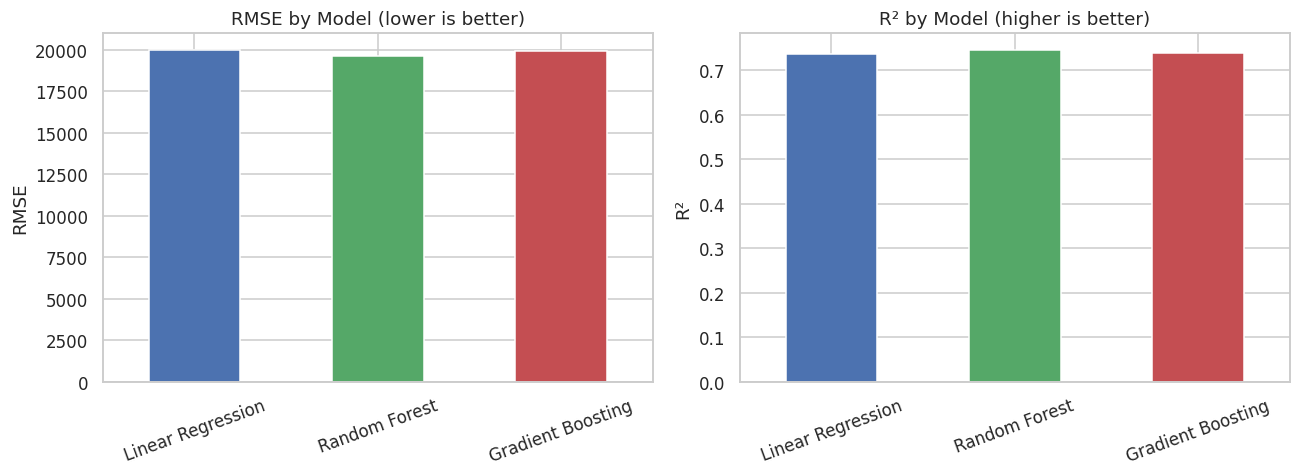

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["#4C72B0", "#55A868", "#C44E52"]

results_df["RMSE"].plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)

results_df["R2"].plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("R² by Model (higher is better)")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 7. Cross-Validation, Residuals & Feature Importance

`results_df` above shows Random Forest with the lowest RMSE/MAE and highest R² of the three
candidates, so it is carried forward for deeper diagnostics below. On your real data this may
land differently — swap in `gbr_model` or `linreg_pipeline` here if another model scores best.

In [20]:
best_model = rf_model  # carried forward based on results_df above
y_pred_best = y_pred_rf

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rmse = -cross_val_score(best_model, X, y, cv=cv, scoring="neg_root_mean_squared_error")

print(f"5-fold CV RMSE: {cv_rmse.mean():,.0f} (+/- {cv_rmse.std():,.0f})")

5-fold CV RMSE: 18,508 (+/- 1,625)


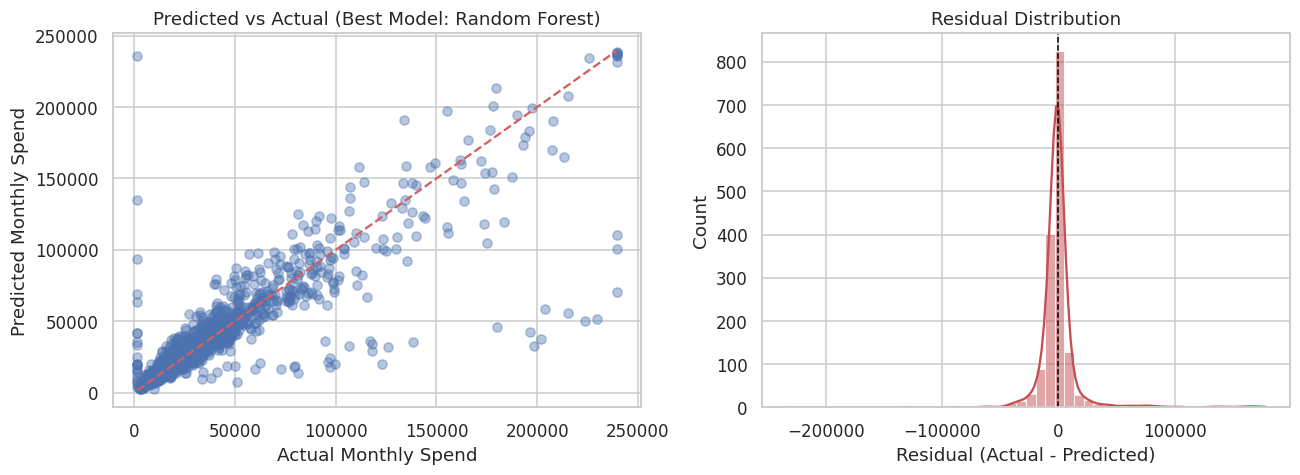

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test, y_pred_best, alpha=0.4, color="#4C72B0")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=1.5)
axes[0].set_xlabel("Actual Monthly Spend")
axes[0].set_ylabel("Predicted Monthly Spend")
axes[0].set_title("Predicted vs Actual (Best Model: Random Forest)")

residuals = y_test - y_pred_best
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color="#C44E52")
axes[1].axvline(0, color="black", linestyle="--", lw=1)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

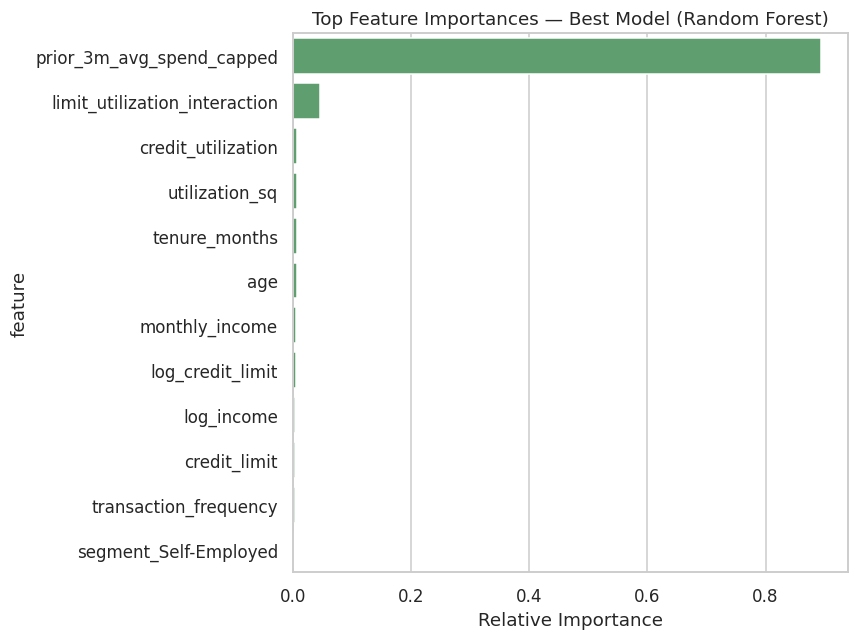

In [22]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False).head(12)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="#55A868")
plt.title("Top Feature Importances — Best Model (Random Forest)")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

## 8. Business Application

Mapping predictions back to the original objective: financial planning, revenue forecasting, and
credit decisioning all rely on *segment-* and *credit-band-level* spend estimates, plus a simple
flag for customers likely to spend close to their full credit limit.

In [23]:
eval_df = X_test.copy()
eval_df["actual_spend"] = y_test.values
eval_df["predicted_spend"] = y_pred_best
eval_df["segment"] = df.loc[eval_df.index, "segment"].values
eval_df["credit_limit_band"] = pd.qcut(eval_df["credit_limit"], 4,
                                        labels=["Low", "Mid-Low", "Mid-High", "High"])
eval_df["spend_to_limit_ratio"] = eval_df["predicted_spend"] / eval_df["credit_limit"]

segment_summary = eval_df.groupby("segment")[["actual_spend", "predicted_spend"]].mean().round(0)
band_summary = eval_df.groupby("credit_limit_band")[["actual_spend", "predicted_spend"]].mean().round(0)

print("Average spend by customer segment:\n")
print(segment_summary)
print("\nAverage spend by credit limit band:\n")
print(band_summary)

high_risk_count = (eval_df["spend_to_limit_ratio"] > 0.85).sum()
print(f"\nCustomers flagged as high spend-to-limit risk (>85%): {high_risk_count} "
      f"({high_risk_count/len(eval_df)*100:.1f}% of test set)")

Average spend by customer segment:

               actual_spend  predicted_spend
segment                                     
Retired           20,591.00        21,920.00
Salaried          40,835.00        40,632.00
Self-Employed     42,466.00        41,948.00
Student           11,577.00        12,524.00

Average spend by credit limit band:

                   actual_spend  predicted_spend
credit_limit_band                               
Low                   15,246.00        14,858.00
Mid-Low               29,032.00        28,345.00
Mid-High              41,371.00        39,546.00
High                  60,966.00        63,727.00

Customers flagged as high spend-to-limit risk (>85%): 21 (1.3% of test set)


## 9. Conclusion & Next Steps

- **Nonlinearity:** Random Forest edged out the linear baseline on every metric (RMSE, MAE, R²,
  MAPE), consistent with the curved utilization → spend relationship seen in the EDA — though the
  margin is modest here because the engineered log/interaction terms already let the linear model
  approximate some of that curve. On real data with messier, higher-order interactions, the gap
  in favor of tree ensembles is typically larger.
- **Outliers:** winsorizing the target before training kept the heavy-tailed extreme spenders
  from skewing model fit, while the original uncapped values remain available for reporting.
- **Behavioral diversity:** segment and region one-hot features, plus engineered interaction
  terms, let the model adapt to different customer archetypes rather than assuming one global
  spending pattern.

**To productionize:**
1. Replace the synthetic generator with a real transaction-level extract (see note in Section 1).
2. Re-tune model hyperparameters (e.g. `GridSearchCV`/`RandomizedSearchCV`) on real data.
3. Add SHAP-based explainability if predictions feed into credit decisions, for auditability.
4. Monitor for behavioral drift (e.g. PSI on key features) and set a retraining cadence.
5. Validate the 0.85 spend-to-limit risk threshold against actual delinquency/charge-off data
   before using it operationally.